# Tarea de clustering

*Taller de proyecto - Grupo 4*

### Objetivo

Identificar perfiles de establecimientos de grupo socioeconómico bajo y medio-bajo según sus características de proceso y contexto, para luego ver qué perfiles se asocian a mejores logros.

### Entidades a agrupar

Establecimientos educacionales de enseñanza media, filtrando al subconjunto de grupo socioeconómico bajo y medio-bajo

### Carga de datos y revisión de distribuciones

Antes de estandarizar, revisamos la forma de cada variable candidata al k-means (histograma + boxplot) para decidir entre `StandardScaler` y `RobustScaler`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_parquet("datos/base_tareas.parquet")

# Filtro a GSE bajo y medio-bajo
df_analisis = df[df["gse"].isin(["Bajo", "Medio bajo"])].copy()

vars_cluster = [
    "convivencia",
    "autoestima_motiv",
    "vida_saludable",
    "participacion",
    "promedio_estandarizado",
]

etiquetas = {
    "convivencia": "Convivencia (0-100)",
    "autoestima_motiv": "Autoestima y motivación (0-100)",
    "vida_saludable": "Vida saludable (0-100)",
    "participacion": "Participación (0-100)",
    "promedio_estandarizado": "Percepciones de género (z-score)",
}

print(f"N muestra analítica (GSE bajo/medio-bajo): {len(df_analisis)}")
df_analisis[vars_cluster].isna().sum().rename("valores_faltantes")

N muestra analítica (GSE bajo/medio-bajo): 1526


convivencia                0
autoestima_motiv           0
vida_saludable             0
participacion              0
promedio_estandarizado    97
Name: valores_faltantes, dtype: int64

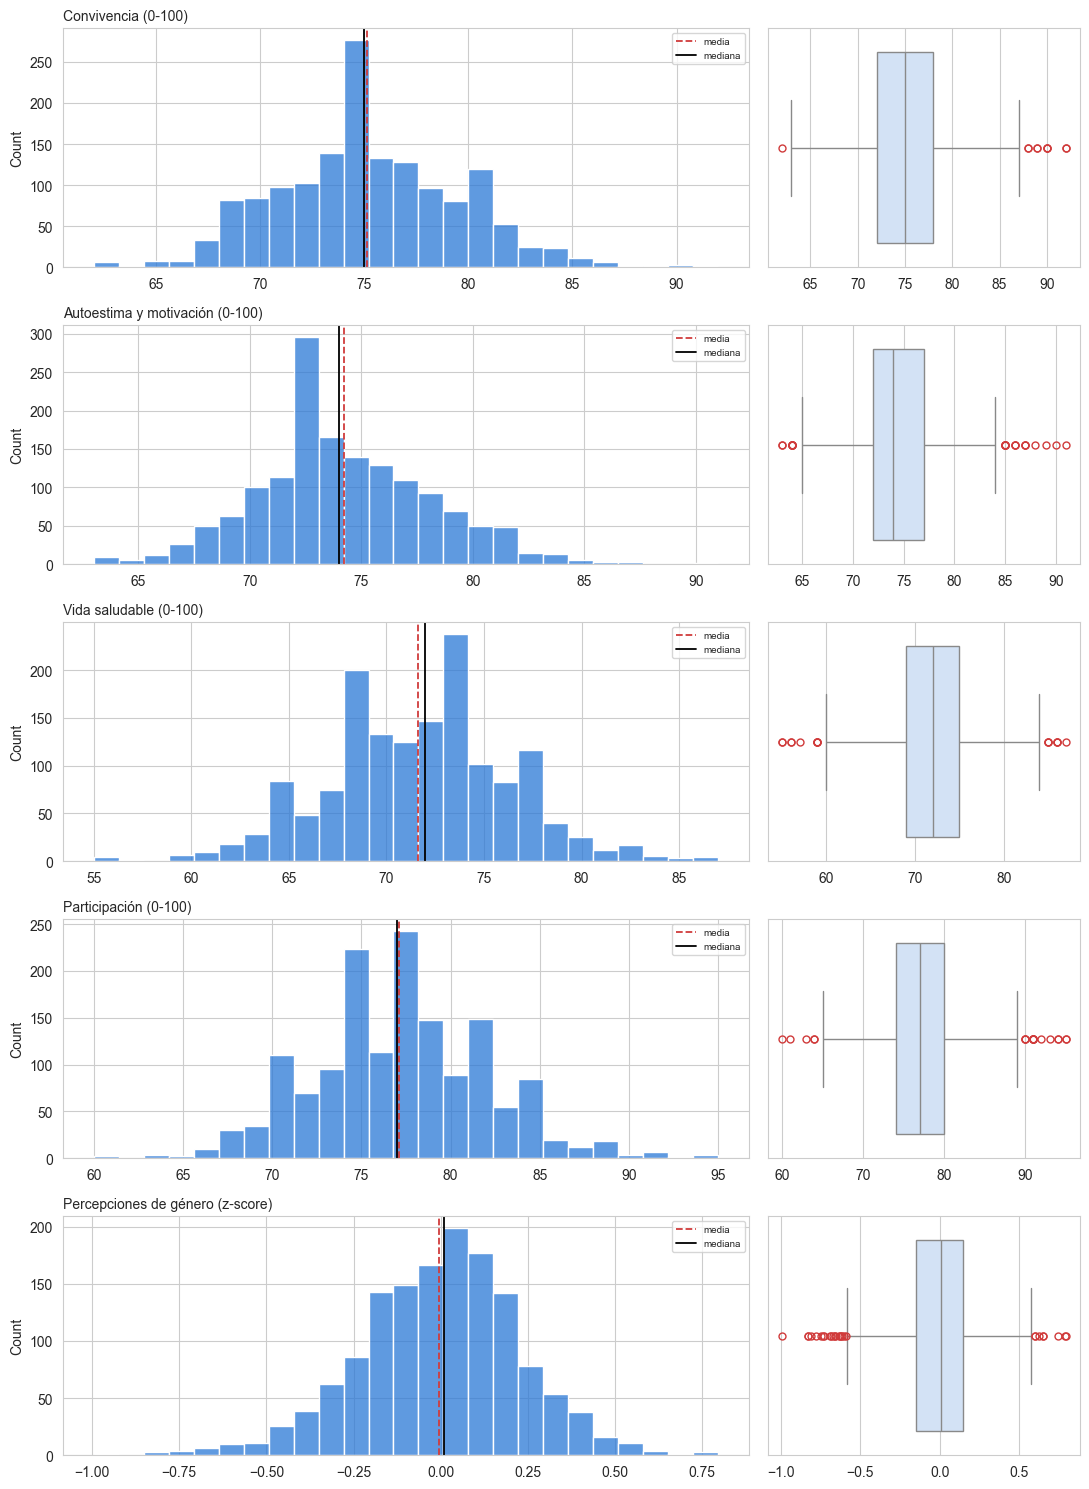

In [2]:
fig, axes = plt.subplots(len(vars_cluster), 2, figsize=(11, 3 * len(vars_cluster)),
                          gridspec_kw={"width_ratios": [2.2, 1]})

for i, var in enumerate(vars_cluster):
    serie = df_analisis[var].dropna()

    # Histograma
    sns.histplot(serie, bins=25, ax=axes[i, 0], color="#2a78d6", edgecolor="white")
    axes[i, 0].axvline(serie.mean(), color="#d03b3b", linestyle="--", linewidth=1.3, label="media")
    axes[i, 0].axvline(serie.median(), color="black", linestyle="-", linewidth=1.3, label="mediana")
    axes[i, 0].set_title(etiquetas[var], fontsize=10, loc="left")
    axes[i, 0].set_xlabel("")
    axes[i, 0].legend(fontsize=7, loc="upper right")

    # Boxplot horizontal
    sns.boxplot(x=serie, ax=axes[i, 1], color="#cde2fb",
                flierprops={"markerfacecolor": "none", "markeredgecolor": "#d03b3b", "markersize": 5})
    axes[i, 1].set_xlabel("")

plt.tight_layout()
plt.show()

In [3]:
from scipy import stats as sstats

resumen = []
for var in vars_cluster:
    serie = df_analisis[var].dropna()
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum()
    resumen.append({
        "variable": var,
        "n": len(serie),
        "faltantes": df_analisis[var].isna().sum(),
        "media": serie.mean(),
        "mediana": serie.median(),
        "sd": serie.std(),
        "asimetria": sstats.skew(serie),
        "curtosis": sstats.kurtosis(serie),
        "outliers_iqr": n_outliers,
        "pct_outliers": round(100 * n_outliers / len(serie), 1),
    })

pd.DataFrame(resumen).set_index("variable").round(3)

,n,faltantes,media,mediana,sd,asimetria,curtosis,outliers_iqr,pct_outliers
variable,,,,,,,,,
convivencia,1526,0,75.140,75.00,4.400,0.229,0.171,10,0.7
autoestima_motiv,1526,0,74.235,74.00,4.039,0.339,0.381,25,1.6
vida_saludable,1526,0,71.636,72.00,4.686,-0.050,0.218,16,1.0
participacion,1526,0,77.123,77.00,4.886,0.188,0.251,20,1.3
promedio_estandarizado,1429,97,-0.004,0.01,0.233,-0.251,0.686,27,1.9


### Exclusión de faltantes y estandarización

Se excluyen las filas con valores faltantes en `promedio_estandarizado` (97 establecimientos sin percepción de género medida) y se estandarizan las 5 variables con `StandardScaler` sobre los establecimientos. 

Se privilegia utilizar `StandardScaler` versus `RobustScaler` porque aunque se detecta presencia de outliers, estos son marginales. Además, las variables provenientes de IDPS son índices construidos a través de cuestionarios agregados por establecimiento (prommedios). Por otro lado, `promedio_estandarizado` es un factor score, que por construcción su distribución se acerca a una normal.

In [4]:
n_antes = len(df_analisis)
df_analisis = df_analisis.dropna(subset=vars_cluster).reset_index(drop=True)
n_despues = len(df_analisis)

print(f"Filas excluidas por faltantes: {n_antes - n_despues}")
print(f"N muestra analítica final: {n_despues}")

Filas excluidas por faltantes: 97
N muestra analítica final: 1429


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_analisis[vars_cluster])
X_scaled = pd.DataFrame(X_scaled, columns=vars_cluster, index=df_analisis.index)

X_scaled.describe().round(3)

,convivencia,autoestima_motiv,vida_saludable,participacion,promedio_estandarizado
count,1429.000,1429.000,1429.000,1429.000,1429.000
mean,0.000,0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-3.016,-2.828,-3.600,-3.531,-4.250
25%,-0.737,-0.578,-0.588,-0.657,-0.622
50%,-0.053,-0.078,0.057,-0.041,0.060
75%,0.631,0.673,0.703,0.575,0.635
max,3.822,4.174,3.284,3.655,3.429


## K-means

### Selección del número de clusters (codo + silhouette)

Antes de fijar k=3, evaluamos un rango de k con dos criterios: la inercia (método del codo) y el silhouette score.

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inercias = []
siluetas = []

for k in k_range:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km_k.fit_predict(X_scaled)
    inercias.append(km_k.inertia_)
    siluetas.append(silhouette_score(X_scaled, labels_k))

eval_k = pd.DataFrame({"k": list(k_range), "inercia": inercias, "silhouette": siluetas}).set_index("k")
eval_k.round(3)

,inercia,silhouette
k,,
2,4156.469,0.342
3,3327.138,0.257
4,2808.746,0.255
5,2466.294,0.231
6,2246.530,0.213
7,2099.817,0.208
8,1964.789,0.198
9,1872.173,0.188
10,1793.048,0.188


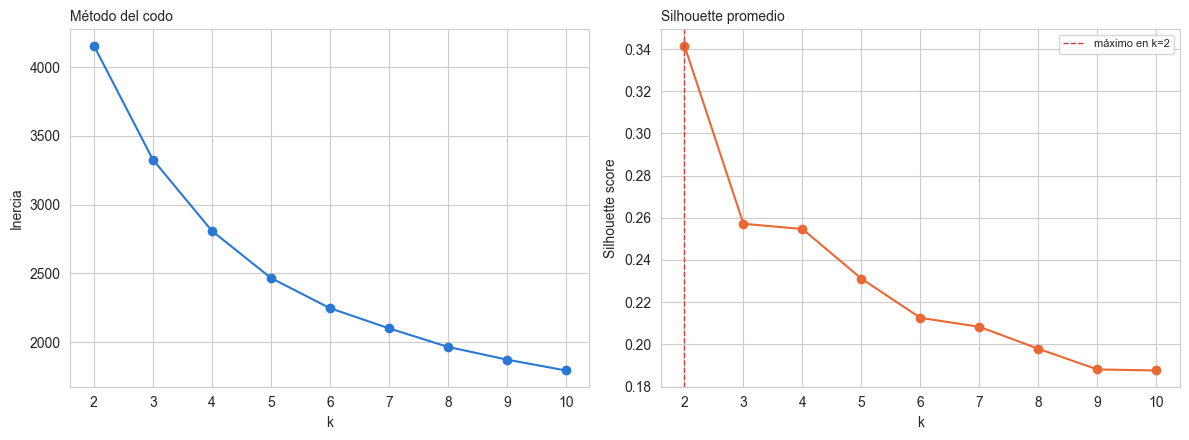

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(eval_k.index, eval_k["inercia"], marker="o", color="#2a78d6")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del codo", fontsize=10, loc="left")
axes[0].set_xticks(list(k_range))

axes[1].plot(eval_k.index, eval_k["silhouette"], marker="o", color="#eb6834")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette promedio", fontsize=10, loc="left")
axes[1].set_xticks(list(k_range))

k_mejor_sil = eval_k["silhouette"].idxmax()
axes[1].axvline(k_mejor_sil, color="#d03b3b", linestyle="--", linewidth=1,
                 label=f"máximo en k={k_mejor_sil}")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Ajuste final con k=2

El silhouette score es máximo en k=2 (0.342) y decae de forma monótona para k mayores. Se elige k=2 como solución final.

In [8]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_analisis["cluster"] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df_analisis["cluster"])
print(f"Inercia: {kmeans.inertia_:.1f}")
print(f"Silhouette score: {sil:.3f}")

df_analisis["cluster"].value_counts().sort_index().rename("n_establecimientos")

Inercia: 4156.5
Silhouette score: 0.342


cluster
0    755
1    674
Name: n_establecimientos, dtype: int64

In [9]:
# Perfil de cada cluster en la escala original de las variables
perfil = df_analisis.groupby("cluster")[vars_cluster].mean().round(3)
perfil["n"] = df_analisis["cluster"].value_counts().sort_index()
perfil

,convivencia,autoestima_motiv,vida_saludable,participacion,promedio_estandarizado,n
cluster,,,,,,
0,72.200,71.609,68.725,73.711,0.003,755
1,78.628,77.335,75.105,81.108,-0.012,674


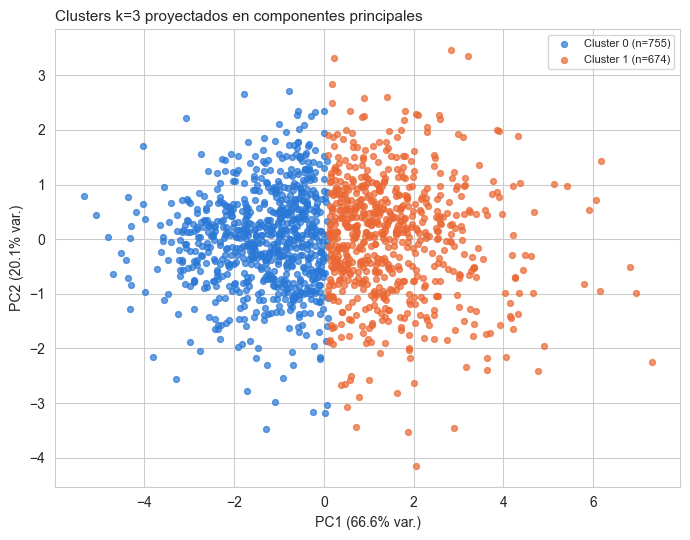

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5.5))
palette = ["#2a78d6", "#eb6834", "#1baf7a"]
for c in sorted(df_analisis["cluster"].unique()):
    mask = df_analisis["cluster"] == c
    ax.scatter(coords[mask, 0], coords[mask, 1], s=18, alpha=0.7,
               color=palette[c], label=f"Cluster {c} (n={mask.sum()})")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.set_title("Clusters k=3 proyectados en componentes principales", fontsize=11, loc="left")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Perfil de clusters por variables categóricas

Se describe la composición de cada cluster según `gse`, `depe` (dependencia administrativa), `zona` (urbano/rural) y `cod_reg_rbd` (región). Los porcentajes están normalizados por cluster (fila), es decir, muestran de qué está compuesto cada cluster.

In [11]:
vars_categoricas = ["gse", "depe", "zona"]

for var in vars_categoricas:
    print(f"--- {var} ---")
    tabla = pd.crosstab(df_analisis["cluster"], df_analisis[var], normalize="index").round(3) * 100
    display(tabla)

--- gse ---


gse,Bajo,Medio bajo
cluster,,
0,42.5,57.5
1,45.1,54.9


--- depe ---


depe,Municipal,Part. subvencionado,SLEP
cluster,,,
0,41.9,49.7,8.5
1,34.1,57.6,8.3


--- zona ---


zona,Rural,Urbano
cluster,,
0,7.4,92.6
1,9.8,90.2


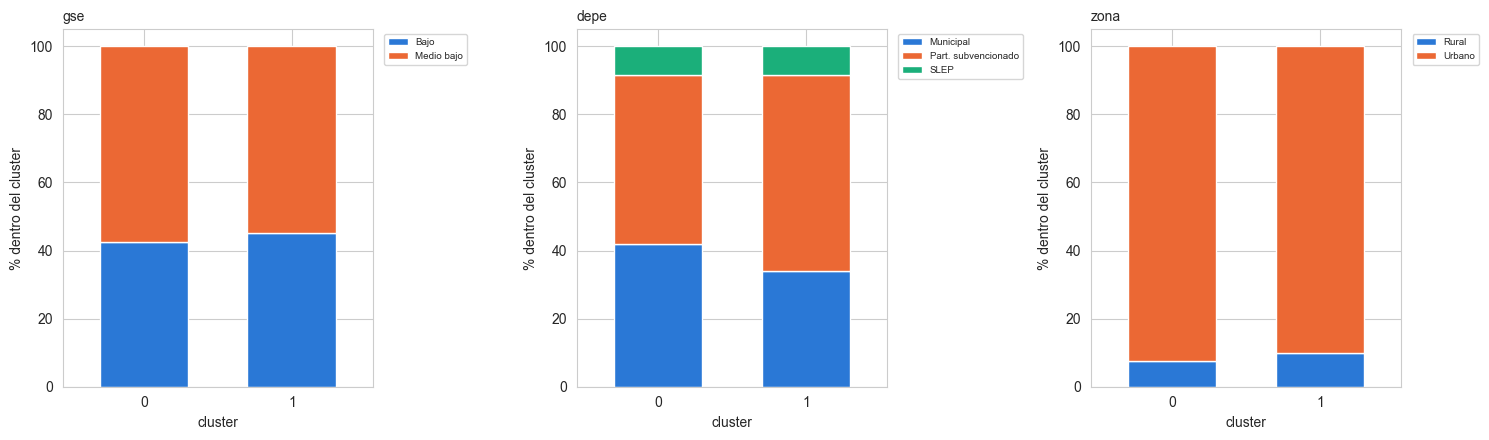

In [12]:
fig, axes = plt.subplots(1, len(vars_categoricas), figsize=(5 * len(vars_categoricas), 4.5))
palette_cat = ["#2a78d6", "#eb6834", "#1baf7a"]

for ax, var in zip(axes, vars_categoricas):
    tabla = pd.crosstab(df_analisis["cluster"], df_analisis[var], normalize="index") * 100
    tabla.plot(kind="bar", stacked=True, ax=ax, color=palette_cat[: tabla.shape[1]], width=0.6)
    ax.set_title(var, fontsize=10, loc="left")
    ax.set_xlabel("cluster")
    ax.set_ylabel("% dentro del cluster")
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

cod_reg_rbd,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
cluster,,,,,,,,,,,,,,,,
0,1.6,2.3,1.3,6.1,12.8,5.6,4.8,7.3,8.5,7.5,0.9,0.9,33.5,3.3,1.2,2.4
1,3.0,1.6,1.2,4.9,9.6,6.4,10.7,10.7,7.9,4.6,1.0,0.6,27.4,3.3,0.9,6.2


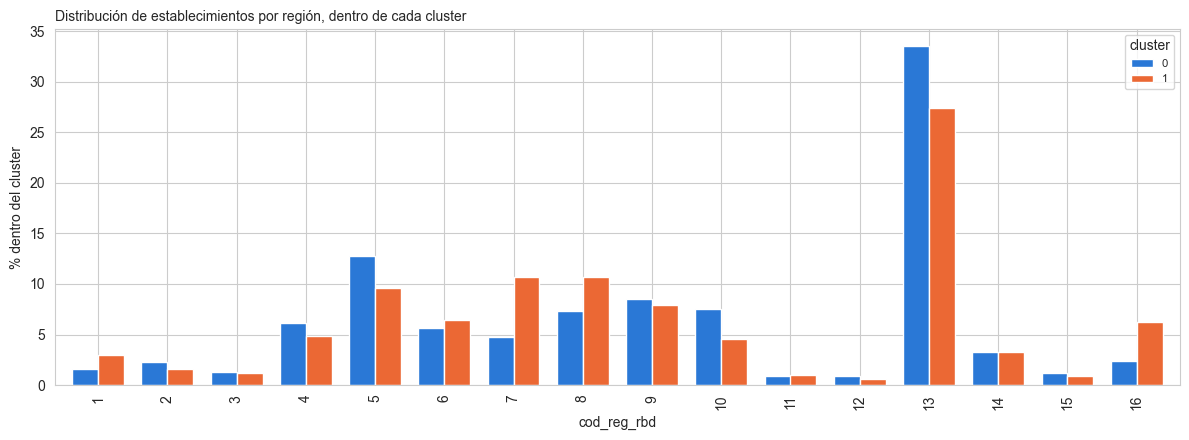

In [13]:
# cod_reg_rbd: distribución de establecimientos por región, dentro de cada cluster
tabla_reg = pd.crosstab(df_analisis["cluster"], df_analisis["cod_reg_rbd"], normalize="index").round(3) * 100
display(tabla_reg)

fig, ax = plt.subplots(figsize=(12, 4.5))
tabla_reg.T.plot(kind="bar", ax=ax, color=palette_cat[:2], width=0.75)
ax.set_xlabel("cod_reg_rbd")
ax.set_ylabel("% dentro del cluster")
ax.set_title("Distribución de establecimientos por región, dentro de cada cluster", fontsize=10, loc="left")
ax.legend(title="cluster", fontsize=8)
plt.tight_layout()
plt.show()

## Cluster vs. logro académico (`prom_mate2m_rbd`)

Se compara la distribución del puntaje promedio de matemática (2° medio) entre ambos clusters.

In [14]:
resumen_mate = df_analisis.groupby("cluster")["prom_mate2m_rbd"].agg(["count", "mean", "median", "std"]).round(2)
resumen_mate

,count,mean,median,std
cluster,,,,
0,755,232.07,230.0,19.88
1,674,244.65,239.5,28.10


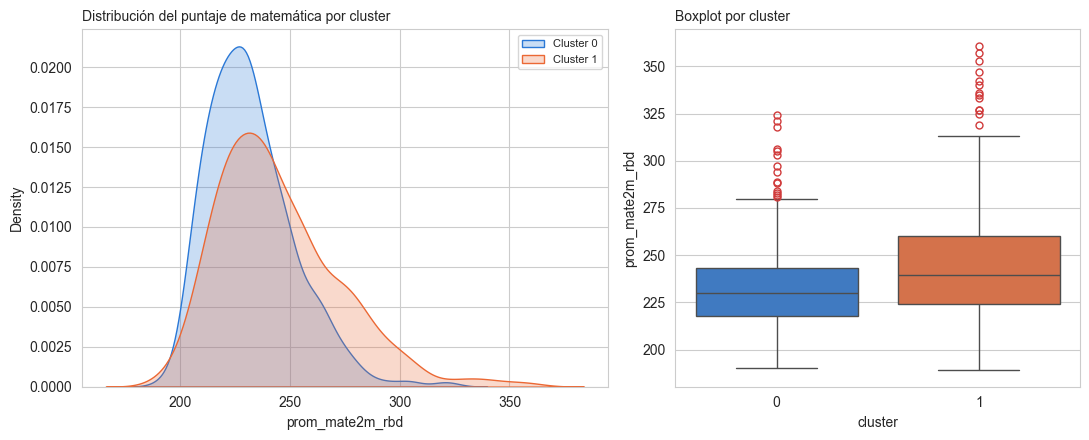

Diferencia de medias (cluster 0 - cluster 1): -12.58
t = -9.663, p-valor = 0.0000


In [15]:
from scipy.stats import ttest_ind

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={"width_ratios": [1.3, 1]})

for c in sorted(df_analisis["cluster"].unique()):
    serie = df_analisis.loc[df_analisis["cluster"] == c, "prom_mate2m_rbd"]
    sns.kdeplot(serie, ax=axes[0], color=palette_cat[c], label=f"Cluster {c}", fill=True, alpha=0.25)

axes[0].set_xlabel("prom_mate2m_rbd")
axes[0].set_title("Distribución del puntaje de matemática por cluster", fontsize=10, loc="left")
axes[0].legend(fontsize=8)

sns.boxplot(data=df_analisis, x="cluster", y="prom_mate2m_rbd", hue="cluster", ax=axes[1],
            palette=palette_cat[:2], legend=False,
            flierprops={"markerfacecolor": "none", "markeredgecolor": "#d03b3b", "markersize": 5})
axes[1].set_title("Boxplot por cluster", fontsize=10, loc="left")

plt.tight_layout()
plt.show()

g0 = df_analisis.loc[df_analisis["cluster"] == 0, "prom_mate2m_rbd"]
g1 = df_analisis.loc[df_analisis["cluster"] == 1, "prom_mate2m_rbd"]
t_stat, p_val = ttest_ind(g0, g1, equal_var=False)
print(f"Diferencia de medias (cluster 0 - cluster 1): {g0.mean() - g1.mean():.2f}")
print(f"t = {t_stat:.3f}, p-valor = {p_val:.4f}")